<a href="https://colab.research.google.com/github/mohamed0barhoomi/final_DATASC/blob/main/last_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler,LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from  sklearn.cluster import KMeans,MiniBatchKMeans,AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score,davies_bouldin_score
import hdbscan
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import plotly.express as px
from sklearn.neighbors import NearestNeighbors

In [5]:
data=pd.read_csv("dataset.csv", sep=",")
print(data.columns)
print(data.head())

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')
   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...

/tmp/ipykernel_3014/992654044.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  data=pd.read_csv("dataset.csv", sep=",")


In [6]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72189 entries, 0 to 72188
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        72189 non-null  int64  
 1   track_id          72189 non-null  object 
 2   artists           72188 non-null  object 
 3   album_name        72188 non-null  object 
 4   track_name        72188 non-null  object 
 5   popularity        72188 non-null  float64
 6   duration_ms       72188 non-null  float64
 7   explicit          72188 non-null  object 
 8   danceability      72188 non-null  float64
 9   energy            72188 non-null  float64
 10  key               72188 non-null  float64
 11  loudness          72188 non-null  float64
 12  mode              72188 non-null  float64
 13  speechiness       72188 non-null  float64
 14  acousticness      72188 non-null  float64
 15  instrumentalness  72188 non-null  float64
 16  liveness          72188 non-null  float6

In [7]:
data.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,72189.000000,72188.000000,7.218800e+04,72188.000000,72188.000000,72188.000000,72188.000000,72188.000000,72188.000000,72188.000000,72188.000000,72188.000000,72188.000000,72188.000000,72188.000000
mean,36094.000000,32.306879,2.298205e+05,0.569795,0.661035,5.322408,-7.888456,0.631241,0.092429,0.282012,0.159443,0.205158,0.463163,122.956450,3.914875
std,20839.313628,22.678883,1.115110e+05,0.174263,0.246790,3.559819,4.779841,0.482472,0.120840,0.321538,0.309532,0.176895,0.253161,29.550557,0.407412
min,0.000000,0.000000,0.000000e+00,0.000000,0.000020,0.000000,-42.044000,0.000000,0.000000,0.000000,0.000000,0.011200,0.000000,0.000000,0.000000
25%,18047.000000,14.000000,1.753745e+05,0.457000,0.497000,2.000000,-9.595000,0.000000,0.036300,0.010500,0.000000,0.097100,0.254000,100.002000,4.000000
50%,36094.000000,31.000000,2.148800e+05,0.579000,0.706000,5.000000,-6.676000,1.000000,0.051000,0.126000,0.000065,0.131000,0.448000,122.846500,4.000000
75%,54141.000000,50.000000,2.647812e+05,0.699000,0.870000,8.000000,-4.782000,1.000000,0.092000,0.521250,0.070200,0.266000,0.664000,141.062000,4.000000
max,72188.000000,100.000000,4.789026e+06,0.984000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,0.999000,0.995000,0.995000,243.372000,5.000000


In [8]:
data.isna().sum()[data.isna().sum()>0]

,0
artists,1
album_name,1
track_name,1
popularity,1
duration_ms,1
explicit,1
danceability,1
energy,1
key,1
loudness,1


In [9]:
data=data.dropna()

print("shape after drop : ",data.shape)

shape after drop :  (72187, 21)


In [10]:
data = data.drop(columns=["Unnamed: 0"])
print("dupliquate in track id : ",data["track_id"].duplicated().sum())
data=data.drop_duplicates(subset="track_id", keep="first").copy()
print("demention after delete dupliquate music track and unamed col (col of index )",data.shape)

dupliquate in track id :  11968
demention after delete dupliquate music track and unamed col (col of index ) (60219, 20)


In [11]:
num_col=[col for col in data.columns if data[col].dtype == "int64" or data[col].dtype == "float64"]
categ_col=[col for col in data.columns if data[col].dtype == "object"]

In [12]:
three_shold=3
for col in num_col:
   z_score=np.abs(stats.zscore(data[col]))
   ouliers=data[z_score>three_shold]
   print("outliers in col {} : {}".format(col,len(ouliers)/data.shape[0]))

outliers in col popularity : 9.963632740497185e-05
outliers in col duration_ms : 0.008386057556585131
outliers in col danceability : 0.0001992726548099437
outliers in col energy : 0.0
outliers in col key : 0.0
outliers in col loudness : 0.020657931881964166
outliers in col mode : 0.0
outliers in col speechiness : 0.01879805377040469
outliers in col acousticness : 0.0
outliers in col instrumentalness : 0.0
outliers in col liveness : 0.029542171075574154
outliers in col valence : 0.0
outliers in col tempo : 0.0005646058552948405
outliers in col time_signature : 0.009282784503229878


In [13]:
print("nombre of genre",data["track_genre"].nunique())
print("nobre of artist",data["artists"].nunique())
print("nb of artist par genre : {}".format(round(data["artists"].nunique()/data["track_genre"].nunique(),2)))


nombre of genre 73
nobre of artist 21143
nb of artist par genre : 289.63


In [14]:
sns.set_style("whitegrid")

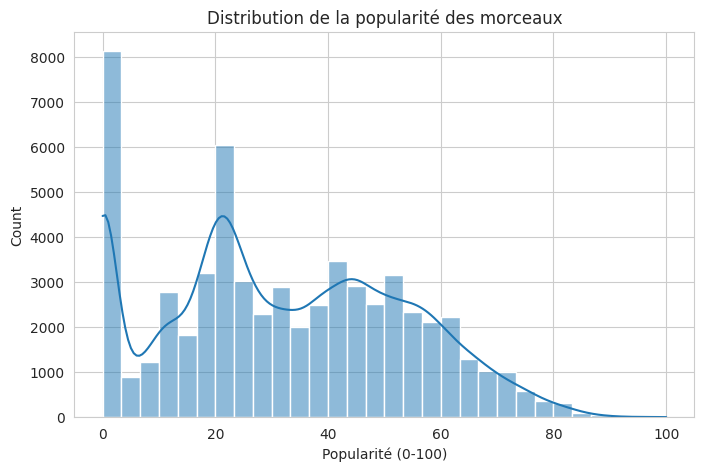

In [15]:

plt.figure(figsize=(8,5))
sns.histplot(data["popularity"],bins=30,kde=True)
plt.title("Distribution de la popularité des morceaux")
plt.xlabel("Popularité (0-100)")
plt.show()

track_genre
k-pop         59.423581
metalcore     58.400000
metal         56.422414
chill         53.738683
latino        51.788945
grunge        50.587007
indian        49.765348
anime         48.776884
emo           48.500000
hard-rock     45.744711
deep-house    45.573045
mandopop      45.071019
british       44.768889
brazil        44.645678
electronic    44.234940
Name: popularity, dtype: float64


Text(0.5, 0, 'popularity moy')

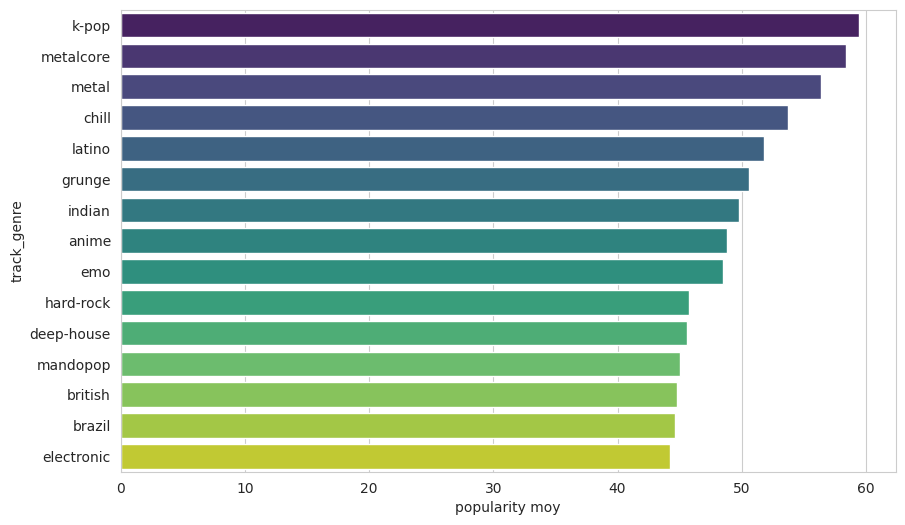

In [16]:
genre_popul=data.groupby(["track_genre"])["popularity"].mean().sort_values(ascending=False).head(15)
print(genre_popul)

plt.figure(figsize=(10,6))
sns.barplot(x=genre_popul.values,y=genre_popul.index,hue=genre_popul.index, palette="viridis", legend=False)
plt.xlabel("popularity moy")

artists
Bad Bunny        85.363636
Lil Nas X        83.200000
Måneskin         82.600000
Eminem           81.166667
Ariana Grande    80.777778
Name: popularity, dtype: float64


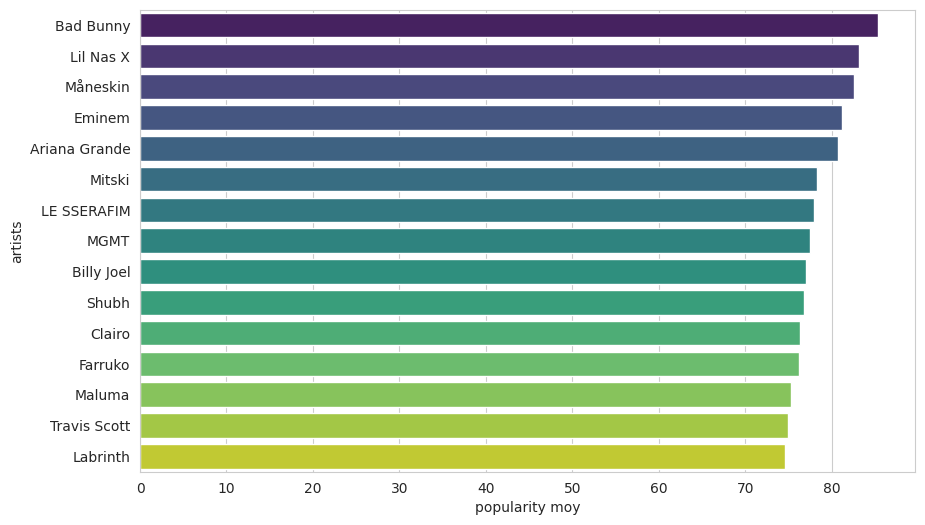

In [17]:
artist_count=data["artists"].value_counts()
principale_art=artist_count[artist_count>3].index

top_artist=(data[data["artists"].isin(principale_art)].groupby("artists")["popularity"].mean().sort_values(ascending=False).head(15))
print(top_artist.head())
plt.figure(figsize=(10,6))
sns.barplot(x=top_artist.values,y=top_artist.index,hue=top_artist.index,palette="viridis", legend=False)
plt.xlabel("popularity moy")
plt.show()

In [18]:
audio_feature = ["danceability", "energy", "valence", "acousticness", "speechiness", "tempo"]
top_genre=genre_popul.head(10).index
print(top_genre)
genre_porc=data[data["track_genre"].isin(top_genre)].groupby("track_genre")[audio_feature].mean()
print(genre_porc)

Index(['k-pop', 'metalcore', 'metal', 'chill', 'latino', 'grunge', 'indian',
       'anime', 'emo', 'hard-rock'],
      dtype='object', name='track_genre')
             danceability    energy   valence  acousticness  speechiness  \
track_genre                                                                
anime            0.537666  0.674229  0.434644      0.267117     0.087429   
chill            0.666423  0.429531  0.408306      0.530572     0.103493   
emo              0.601147  0.667745  0.441194      0.191794     0.112685   
grunge           0.455414  0.804870  0.400566      0.047791     0.061500   
hard-rock        0.479286  0.807106  0.510132      0.079862     0.068861   
indian           0.585930  0.554673  0.448285      0.511175     0.068742   
k-pop            0.641783  0.682796  0.568961      0.294774     0.085454   
latino           0.755487  0.712343  0.622474      0.208931     0.121987   
metal            0.481177  0.841392  0.424929      0.035705     0.077117   
metalcor

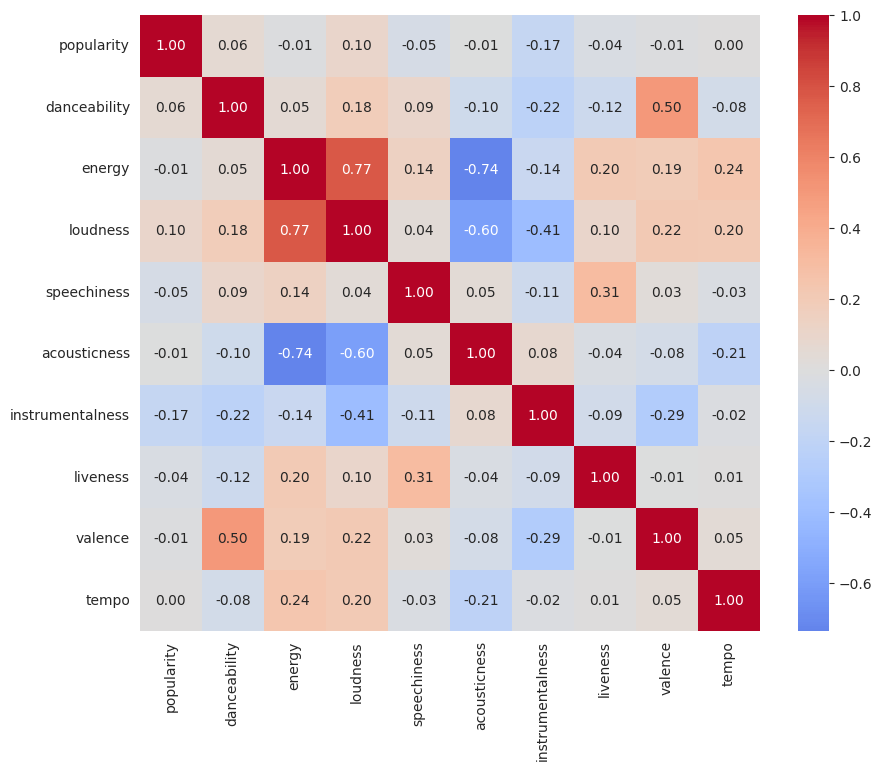

In [19]:
corr_features = ["popularity","danceability","energy","loudness","speechiness",
                  "acousticness","instrumentalness","liveness","valence","tempo"]
plt.figure(figsize=(10,8))
sns.heatmap(data[corr_features].corr(),annot=True,fmt=".2f",cmap="coolwarm",center=0)
plt.show()

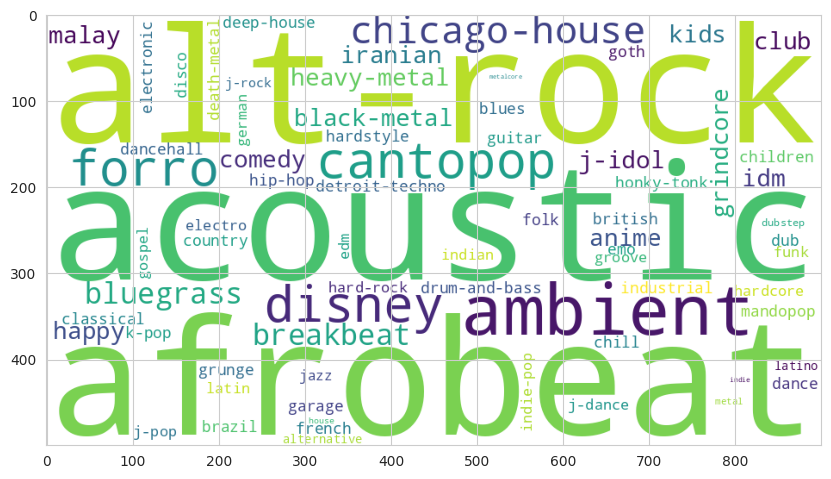

In [20]:
genre_fr = data["track_genre"].value_counts().to_dict()

wc_genre = WordCloud(width=900, height=500,background_color="white",colormap="viridis").generate_from_frequencies(genre_fr)
plt.figure(figsize=(10,10))
plt.imshow(wc_genre)
plt.show()

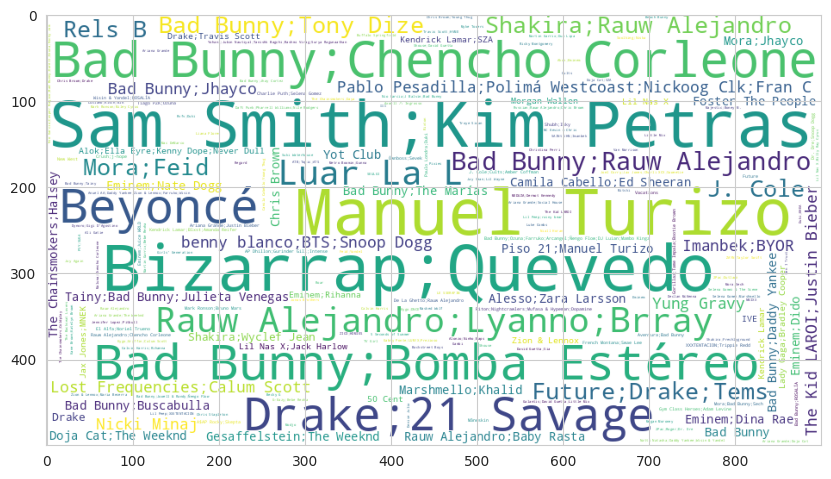

In [21]:
artist_fr=data.groupby("artists")["popularity"].mean().sort_values(ascending=False).head(200).to_dict()
wc_artist = WordCloud(width=900, height=500, background_color="white",
                       colormap="viridis").generate_from_frequencies(artist_fr)
plt.figure(figsize=(10,10))
plt.imshow(wc_artist)
plt.show()

In [22]:
fut_princ=["danceability", "energy", "loudness", "speechiness","acousticness", "instrumentalness", "liveness","valence", "tempo"]
princ_data=data[fut_princ].copy()
print(princ_data.head())
scaler=StandardScaler()
princ_data=scaler.fit_transform(princ_data)
print(data.isna().sum())
data=data.dropna()


   danceability  energy  loudness  speechiness  acousticness  \
0         0.676  0.4610    -6.746       0.1430        0.0322   
1         0.420  0.1660   -17.235       0.0763        0.9240   
2         0.438  0.3590    -9.734       0.0557        0.2100   
3         0.266  0.0596   -18.515       0.0363        0.9050   
4         0.618  0.4430    -9.681       0.0526        0.4690   

   instrumentalness  liveness  valence    tempo  
0          0.000001    0.3580    0.715   87.917  
1          0.000006    0.1010    0.267   77.489  
2          0.000000    0.1170    0.120   76.332  
3          0.000071    0.1320    0.143  181.740  
4          0.000000    0.0829    0.167  119.949  
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrum

In [23]:
inertie=[]
for k in range(2,13):
    km=KMeans(n_clusters=k,random_state=42, n_init=10)
    km.fit(princ_data)
    inertie.append(km.inertia_)
print(inertie)

[429683.39734999085, 376256.48942228145, 330858.4376709294, 298568.12501237437, 271803.0828951955, 249884.63747116685, 235313.5144948007, 224793.72254670935, 215267.3495211257, 207793.33072650133, 200660.1035640153]


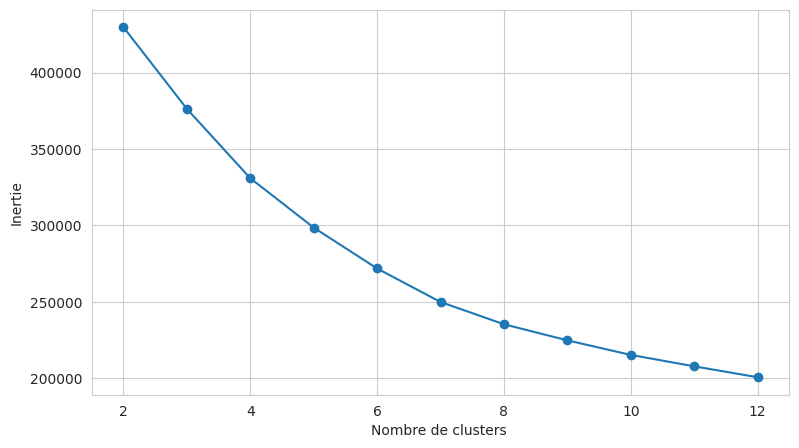

In [24]:
plt.figure(figsize=(9,5))
plt.plot(list(range(2,13)), inertie, marker="o")
plt.xlabel("Nombre de clusters ")
plt.ylabel("Inertie")
plt.show()

In [25]:
part_indx = np.random.RandomState(42).choice(len(princ_data), size=5000, replace=False)
part_data = princ_data[part_indx]
print(princ_data.shape)
print(part_data.shape)

(60219, 9)
(5000, 9)


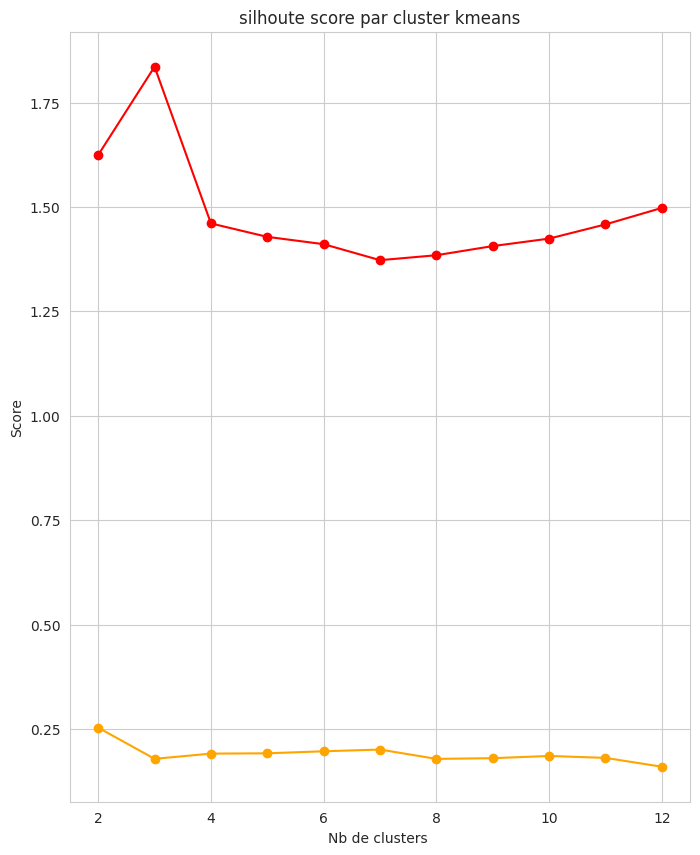

In [26]:
sil_scores = []
DVB=[]
for k in range(2,13):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    pred = km.fit_predict(part_data)
    sil_scores.append(silhouette_score(part_data, pred))
    DVB.append(davies_bouldin_score(part_data, pred))
plt.figure(figsize=(8,10))
plt.plot(list(range(2,13)), sil_scores, marker="o", color="orange")
plt.plot(list(range(2,13)), DVB, marker="o", color="red")
plt.xlabel("Nb de clusters ")
plt.ylabel("Score")
plt.title("silhoute score par cluster kmeans")
plt.show()

In [27]:
print("silhoutte de k=8 :",sil_scores[6])
print("DVB de k=8 : ",DVB[6])

silhoutte de k=8 : 0.1784475507242872
DVB de k=8 :  1.384337588770776


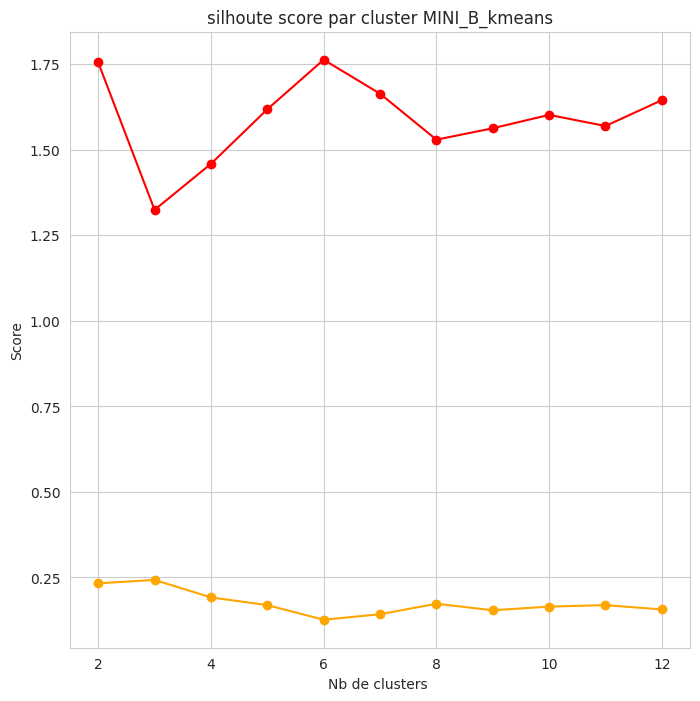

In [28]:
sil_scores = []
DVB=[]
for k in range(2,13):
    km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=500)
    pred = km.fit_predict(part_data)
    sil_scores.append(silhouette_score(part_data, pred))
    DVB.append(davies_bouldin_score(part_data, pred))
plt.figure(figsize=(8,8))
plt.plot(list(range(2,13)), sil_scores, marker="o", color="orange")
plt.plot(list(range(2,13)), DVB, marker="o", color="red")
plt.xlabel("Nb de clusters ")
plt.ylabel("Score")
plt.title("silhoute score par cluster MINI_B_kmeans")
plt.show()

In [29]:
print("silhoutte de k=8 :", sil_scores[6])
print("DVB de k=8 : ", DVB[6])

silhoutte de k=8 : 0.1732475469535599
DVB de k=8 :  1.5296151733633452


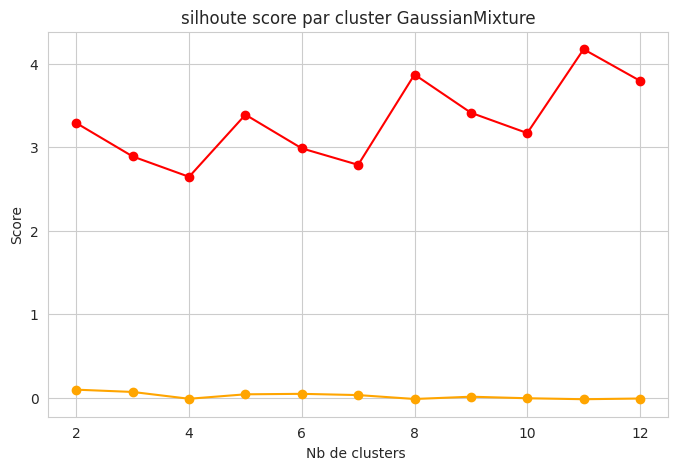

In [30]:
sil_scores = []
DVB=[]
for k in range(2,13):
    Gm = GaussianMixture( n_components=k,covariance_type='full',random_state=42)
    pred = Gm.fit_predict(part_data)
    sil_scores.append(silhouette_score(part_data, pred))
    DVB.append(davies_bouldin_score(part_data, pred))

plt.figure(figsize=(8,5))
plt.plot(list(range(2,13)), sil_scores, marker="o", color="orange")
plt.plot(list(range(2,13)), DVB, marker="o", color="red")

plt.xlabel("Nb de clusters ")
plt.ylabel("Score")
plt.title("silhoute score par cluster GaussianMixture")
plt.show()

In [31]:
print("silhoutte de k=8 :",sil_scores[6])
print("DVB de k=8 : ",DVB[6])

silhoutte de k=8 : -0.0167239459772751
DVB de k=8 :  3.872932776246962


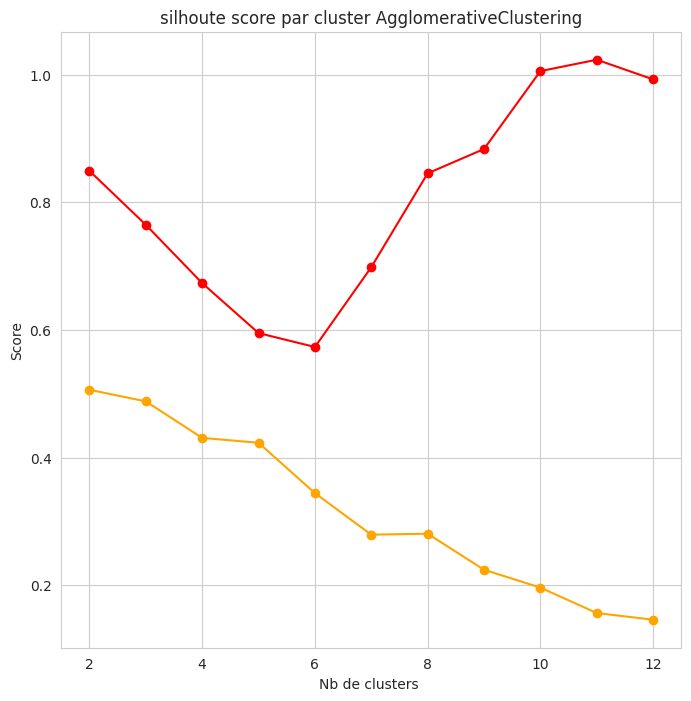

In [32]:
sil_scores = []
DVB=[]
for k in range(2,13):
    agg = AgglomerativeClustering(n_clusters=k, linkage='average')
    pred = agg.fit_predict(part_data)
    sil_scores.append(silhouette_score(part_data, pred))
    DVB.append(davies_bouldin_score(part_data, pred))
plt.figure(figsize=(8,8))
plt.plot(list(range(2,13)), sil_scores, marker="o", color="orange")
plt.plot(list(range(2,13)),DVB, marker="o", color="red")
plt.xlabel("Nb de clusters ")
plt.ylabel("Score")
plt.title("silhoute score par cluster AgglomerativeClustering")
plt.show()

In [33]:
print("silhoutte de k=8 :",sil_scores[4])
print("DVB de k=8 : ",DVB[4])

silhoutte de k=8 : 0.3443641570523656
DVB de k=8 :  0.5733269056412224


In [34]:
sil_scores = []
DVB=[]
model = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=10)
pred = model.fit_predict(part_data)
sil_scores.append(silhouette_score(part_data, pred))
DVB.append(davies_bouldin_score(part_data, pred))
print("silhoutte de k=8 :",sil_scores[0])
print("DVB de k=8 : ",DVB[0])

silhoutte de k=8 : 0.4046205974237702
DVB de k=8 :  1.7685886776543411


In [35]:
# k=8 is the best nbr of cluster in Kmeans and k=6 is the best nbr of cluster in agg so i try to use both
# k=8 is the best nbr of cluster in Kmeans and k=6 is the best nbr of cluster in agg so i try to use both
# k=8 is the best nbr of cluster in Kmeans and k=6 is the best nbr of cluster in agg so i try to use both
k_KM=8

In [36]:
# k_agg=6
# pred=[]
# pred_agg=pd.DataFrame(pred)
# agg_model = AgglomerativeClustering(n_clusters=k_agg, linkage='average')
# pred_agg["cluster"]=agg_model.fit_predict(princ_data)
# print(pred_agg.value_counts().sort_values(ascending=False))


# i can't use this model !!!!!!!!!!!!!!!!!!!!! cause of memory

In [37]:

genre_df = pd.read_csv("data_by_genres.csv")
print("Shape original :", genre_df.shape)

genre_df = genre_df[genre_df["genres"].str.strip() != "[]"].copy()
genre_df = genre_df.dropna(subset=["genres"]).reset_index(drop=True)
print("Shape après nettoyage :", genre_df.shape)
genre_df.head()

Shape original : (2973, 14)
Shape après nettoyage : (2972, 14)


,mode,genres,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,1,21st century classical,0.979333,0.162883,1.602977e+05,0.071317,0.606834,0.361600,-31.514333,0.040567,75.336500,0.103783,27.833333,6
1,1,432hz,0.494780,0.299333,1.048887e+06,0.450678,0.477762,0.131000,-16.854000,0.076817,120.285667,0.221750,52.500000,5
2,1,8-bit,0.762000,0.712000,1.151770e+05,0.818000,0.876000,0.126000,-9.180000,0.047000,133.444000,0.975000,48.000000,7
3,1,a cappella,0.676557,0.538961,1.906285e+05,0.316434,0.003003,0.172254,-12.479387,0.082851,112.110362,0.448249,45.820071,7
4,1,abstract,0.459210,0.516167,3.431965e+05,0.442417,0.849667,0.118067,-15.472083,0.046517,127.885750,0.307325,43.500000,1


In [38]:
scaler_genre = StandardScaler()
data_genre = scaler_genre.fit_transform(genre_df[fut_princ])
print(data_genre)

[[-2.48432022 -2.08926443 -3.91221519 ...  1.82784035 -1.92725355
  -2.5007007 ]
 [-1.57868449 -0.47132341 -1.18171535 ... -0.66906228 -1.34273793
   0.07240734]
 [ 1.16023582  1.09526817  0.24757383 ... -0.72320154  2.38955698
   0.82565408]
 ...
 [ 1.405072    0.26124254  0.04098022 ... -1.11649318  1.64191432
  -0.97634365]
 [ 1.1182007  -1.65701643 -0.17583648 ... -0.14210683  1.22019541
  -1.58813202]
 [ 0.61206723  0.20547723  0.12188701 ...  0.6830829   1.56477877
   0.42048007]]


In [39]:
km_genre = KMeans(n_clusters=8, random_state=42, n_init=10)
genre_df["cluster"] = km_genre.fit_predict(data_genre)

print("nbr des genres par cluster :")
print(genre_df["cluster"].value_counts().sort_index())

nbr des genres par cluster :
cluster
0    588
1    780
2    363
3    254
4    653
5     67
6    246
7     21
Name: count, dtype: int64


In [40]:
CLUSTER_NAME = {
    0:  "Electronic & Chill Instrumentals",
    1:  "Peaceful Acoustic & Classical",
    2:  "Feel-Good Dance & Pop",
    3:  "Heavy Punk & Metal",
    4:  "Hip-Hop & Dance Beats",
    5:  "Comedy & Spoken Audio",
    6:  "Relaxing Classical Instrumentals",
    7:  "Hard Rock & Heavy Metal"
}

genre_df["cluster_name"] = genre_df["cluster"].map(CLUSTER_NAME)

for c, name in CLUSTER_NAME.items():
    count = (genre_df["cluster"] == c).sum()
    sample_genres = genre_df[genre_df["cluster"] == c]["genres"].tolist()[:4]
    print(f"Cluster {c:2d} : {name:<40} nbr genre : {count:4d} genres | ex: {','.join(sample_genres)}")

Cluster  0 : Electronic & Chill Instrumentals         nbr genre :  588 genres | ex: acid rock,action rock,adoracion,african percussion
Cluster  1 : Peaceful Acoustic & Classical            nbr genre :  780 genres | ex: abstract beats,acoustic punk,afghan pop,african reggae
Cluster  2 : Feel-Good Dance & Pop                    nbr genre :  363 genres | ex: 21st century classical,432hz,acousmatic,african-american classical
Cluster  3 : Heavy Punk & Metal                       nbr genre :  254 genres | ex: 8-bit,abstract,acid house,acid trance
Cluster  4 : Hip-Hop & Dance Beats                    nbr genre :  653 genres | ex: a cappella,accordeon,accordion,acoustic blues
Cluster  5 : Comedy & Spoken Audio                    nbr genre :   67 genres | ex: arabic hip hop,atmospheric post-metal,atmospheric sludge,australian underground hip hop
Cluster  6 : Relaxing Classical Instrumentals         nbr genre :  246 genres | ex: abstract hip hop,afro dancehall,afro soul,afrofuturism
Cluster  7 :

In [41]:
profile = genre_df.groupby("cluster_name")[fut_princ + ["popularity"]].mean().round(3)
profile

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,popularity
cluster_name,,,,,,,,,,
Comedy & Spoken Audio,0.504,0.594,-10.642,0.093,0.459,0.326,0.577,0.474,113.569,33.247
Electronic & Chill Instrumentals,0.457,0.793,-6.470,0.079,0.105,0.118,0.212,0.415,132.945,45.079
Feel-Good Dance & Pop,0.327,0.172,-21.252,0.051,0.877,0.603,0.153,0.229,103.703,31.259
Hard Rock & Heavy Metal,0.604,0.377,-16.903,0.763,0.723,0.025,0.387,0.457,102.264,13.306
Heavy Punk & Metal,0.551,0.679,-9.507,0.063,0.172,0.617,0.183,0.407,121.644,38.163
Hip-Hop & Dance Beats,0.526,0.377,-12.336,0.064,0.693,0.156,0.181,0.505,114.356,31.342
Peaceful Acoustic & Classical,0.644,0.651,-8.234,0.066,0.283,0.065,0.174,0.668,119.417,45.618
Relaxing Classical Instrumentals,0.719,0.671,-7.130,0.209,0.200,0.033,0.185,0.576,119.675,51.044


In [42]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(data_genre)

genre_df["tsne_1"] = tsne_result[:, 0]
genre_df["tsne_2"] = tsne_result[:, 1]

In [43]:

fig_genre = px.scatter(
    genre_df,
    x="tsne_1",
    y="tsne_2",
    color="cluster_name",
    hover_name="genres",
    hover_data={
        "cluster_name":   True,
        "popularity":     ":.1f",
        "danceability":   ":.3f",
        "energy":         ":.3f",
        "valence":        ":.3f",
        "acousticness":   ":.3f",
        "tempo":          ":.1f",
        "tsne_1":         False,
        "tsne_2":         False,
    },
    title="<b>Clustering des Genres Musicaux using T-SNE with k=8</b>",
    labels={"color": "Groupe"},
    color_discrete_sequence=px.colors.qualitative.Set3,
    width=1000,
    height=700,
)
fig_genre.update_traces(marker=dict(size=7, line=dict(width=0.5, color="white")))
fig_genre.update_layout(
    title_font_size=16,
    legend_title_text="Groupe musical",
    plot_bgcolor="white",
    paper_bgcolor="white",
    legend=dict(font=dict(size=11)),
)
fig_genre.show()

In [44]:
data_songs = scaler.fit_transform(data[fut_princ])
print(f"Données chansons standardisées : {data_songs.shape}")

Données chansons standardisées : (60219, 9)


In [45]:
km_songs = KMeans(n_clusters=25, random_state=42, n_init=10)
data = data.copy()
data["cluster"] = km_songs.fit_predict(data_songs)

print("Distribution des chansons par cluster :")
print(data["cluster"].value_counts().sort_index())

Distribution des chansons par cluster :
cluster
0     2523
1     3688
2     3697
3     2045
4      870
5     3005
6     3219
7     2011
8     2872
9     1621
10    3494
11    1124
12    2774
13    1600
14    4919
15    2287
16    2460
17     724
18    1945
19    2750
20    2096
21    1385
22    1953
23    3635
24    1522
Name: count, dtype: int64


In [46]:
SONG_CLUSTER_NAMES = {
    0:  "Chill Study & Instrumental Guitar",
    1:  "Electronic Dance & EDM",
    2:  "Disco, Latin & Dance Floor",
    3:  "Asian & Bollywood Pop",
    4:  "Sleep, Piano & Deep Ambient",
    5:  "Energetic Pop & Punk (J-Idol / Ska)",
    6:  "Comedy, Kids & Show Tunes",
    7:  "Tango, Country & Acoustic Romance",
    8:  "World Music, Dub & Gospel",
    9:  "Brazilian Music (Samba / Pagode)",
    10: "Opera, Jazz & Disney Classics",
    11: "Heavy Metal & Grunge",
    12: "J-Dance, Hardstyle & Dancehall",
    13: "New Age, Persian & Ambient Classical",
    14: "Soft Asian Pop & Acoustic Romance",
    15: "Extreme Energy (Hardstyle / DnB / Metal)",
    16: "Extreme Metal (Black / Death / Grind)",
    17: "Folk, Salsa & Country Roots",
    18: "Dancehall, Funk & Kids Party",
    19: "Energetic Live World & Metal Mix",
    20: "Techno, Trance & IDM",
    21: "Salsa, Rock-n-Roll & Bluegrass",
    22: "House, Afrobeat & Breakbeat",
    23: "Party & High Energy Pop",
    24: "Dark Sleep & World Ambient",
}


data["cluster_name"] = data["cluster"].map(SONG_CLUSTER_NAMES)

for c, name in SONG_CLUSTER_NAMES.items():
    count = (data["cluster"] == c).sum()
    # ✅ Erreur 2 corrigée : track_genre au lieu de track_name (tu voulais afficher des genres, pas des titres)
    sample_genres = data[data["cluster"] == c]["track_genre"].tolist()[:4]
    print(f"Cluster {c:2d} : {name:<42} | nbr songs : {count:5d} | ex: {', '.join(sample_genres)}")

Cluster  0 : Chill Study & Instrumental Guitar          | nbr songs :  2523 | ex: acoustic, acoustic, acoustic, acoustic
Cluster  1 : Electronic Dance & EDM                     | nbr songs :  3688 | ex: acoustic, acoustic, acoustic, acoustic
Cluster  2 : Disco, Latin & Dance Floor                 | nbr songs :  3697 | ex: acoustic, acoustic, acoustic, acoustic
Cluster  3 : Asian & Bollywood Pop                      | nbr songs :  2045 | ex: acoustic, acoustic, acoustic, afrobeat
Cluster  4 : Sleep, Piano & Deep Ambient                | nbr songs :   870 | ex: afrobeat, afrobeat, afrobeat, ambient
Cluster  5 : Energetic Pop & Punk (J-Idol / Ska)        | nbr songs :  3005 | ex: acoustic, acoustic, acoustic, acoustic
Cluster  6 : Comedy, Kids & Show Tunes                  | nbr songs :  3219 | ex: acoustic, acoustic, acoustic, acoustic
Cluster  7 : Tango, Country & Acoustic Romance          | nbr songs :  2011 | ex: acoustic, acoustic, acoustic, acoustic
Cluster  8 : World Music, Dub & G

In [47]:
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(data_songs)

data["pca_1"] = pca_result[:, 0]
data["pca_2"] = pca_result[:, 1]

print(f"Variance expliquée par les 2 composantes PCA : {pca.explained_variance_ratio_.sum():.2%}")

sample_viz = data.sample(8000, random_state=42)

fig_songs = px.scatter(
    sample_viz,
    x="pca_1",
    y="pca_2",
    color=sample_viz["cluster"].astype(str),
    hover_name="track_name",
    hover_data={
        "artists":      True,
        "track_genre":  True,
        "popularity":   True,
        "pca_1":        False,
        "pca_2":        False,
        "cluster":      False,
    },
    title="<b>Clustering des Chansons — PCA k=25, échantillon of  8000 ligne</b>",
    labels={"color": "Cluster"},
    color_discrete_sequence=px.colors.qualitative.Alphabet,
    width=1000,
    height=700,
    opacity=0.7,
)
fig_songs.update_traces(marker=dict(size=5))
fig_songs.update_layout(
    title_font_size=16,
    legend_title_text="Cluster",
    plot_bgcolor="white",
    paper_bgcolor="white",
)
fig_songs.show()

Variance expliquée par les 2 composantes PCA : 48.04%


In [48]:
song_cluster_profile = data.groupby("cluster")[fut_princ].mean().round(3)
song_cluster_profile

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
0,0.600,0.246,-13.849,0.049,0.820,0.025,0.143,0.414,109.999
1,0.650,0.805,-5.329,0.065,0.063,0.037,0.142,0.367,125.558
2,0.402,0.901,-4.394,0.100,0.030,0.032,0.206,0.332,163.371
3,0.679,0.677,-9.869,0.062,0.088,0.794,0.140,0.227,121.963
4,0.561,0.709,-11.194,0.893,0.795,0.003,0.736,0.429,98.424
5,0.638,0.848,-5.009,0.068,0.101,0.021,0.353,0.673,123.570
6,0.583,0.804,-5.421,0.071,0.182,0.018,0.154,0.757,162.234
7,0.273,0.113,-23.780,0.047,0.879,0.835,0.134,0.139,98.999
8,0.572,0.803,-5.325,0.066,0.119,0.015,0.142,0.649,97.268


In [49]:
for c in sorted(data["cluster"].unique())[:10]:
    top_g = data[data["cluster"] == c]["track_genre"].value_counts().head(3)
    print(f"Cluster {c} — top genres : {', '.join(top_g.index.tolist())}")

Cluster 0 — top genres : honky-tonk, acoustic, jazz
Cluster 1 — top genres : deep-house, edm, dance
Cluster 2 — top genres : hardstyle, happy, drum-and-bass
Cluster 3 — top genres : detroit-techno, idm, chicago-house
Cluster 4 — top genres : comedy, children, kids
Cluster 5 — top genres : j-idol, disco, forro
Cluster 6 — top genres : forro, j-idol, country
Cluster 7 — top genres : ambient, classical, iranian
Cluster 8 — top genres : alt-rock, k-pop, grunge
Cluster 9 — top genres : grindcore, black-metal, death-metal


Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre', 'cluster',
       'cluster_name', 'pca_1', 'pca_2'],
      dtype='object')


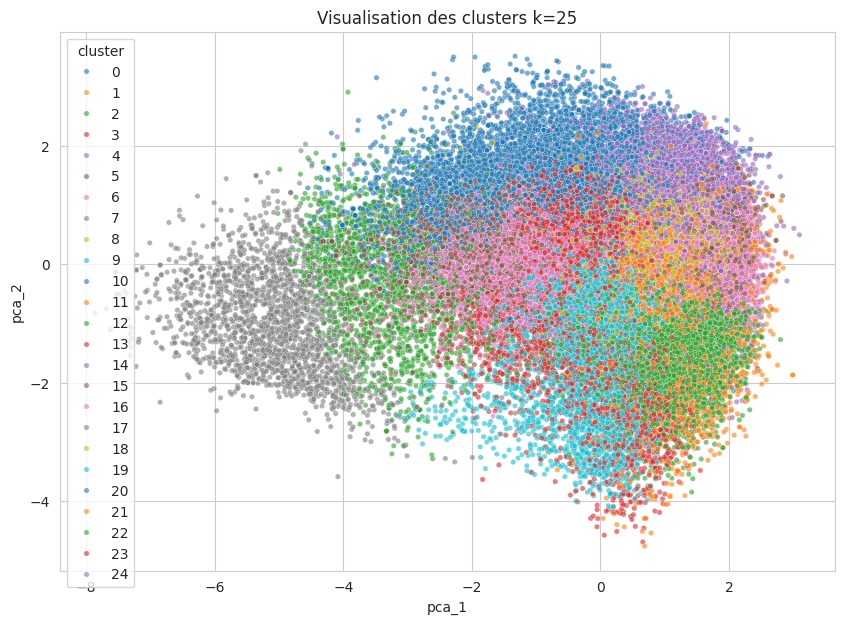

Variance expliquée par les 2 composantes : 48.04%


In [50]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(princ_data)

data["pca_1"] = X_pca[:, 0]
data["pca_2"] = X_pca[:, 1]
print(data.columns)
plt.figure(figsize=(10,7))
sns.scatterplot(data=data, x="pca_1", y="pca_2", hue="cluster",
                 palette="tab10", s=15, alpha=0.6)
plt.title(f"Visualisation des clusters k=25")
plt.show()

print(f"Variance expliquée par les 2 composantes : {pca.explained_variance_ratio_.sum():.2%}")

In [51]:
for claster in sorted(data["cluster"].unique()):
    top_genres_cluster = data[data["cluster"] == claster]["track_genre"].value_counts().head(5)
    print(f"\nCluster {claster} — have as genres :")
    print(top_genres_cluster)


Cluster 0 — have as genres :
track_genre
honky-tonk    336
acoustic      215
jazz          153
chill         146
cantopop      129
Name: count, dtype: int64

Cluster 1 — have as genres :
track_genre
deep-house    236
edm           229
dance         170
industrial    154
electronic    125
Name: count, dtype: int64

Cluster 2 — have as genres :
track_genre
hardstyle        327
happy            270
drum-and-bass    233
heavy-metal      211
grunge           209
Name: count, dtype: int64

Cluster 3 — have as genres :
track_genre
detroit-techno    385
idm               215
chicago-house     188
club              168
deep-house        164
Name: count, dtype: int64

Cluster 4 — have as genres :
track_genre
comedy      793
children     12
kids         12
jazz          7
french        6
Name: count, dtype: int64

Cluster 5 — have as genres :
track_genre
j-idol      194
disco       157
forro       119
alt-rock    105
j-pop        98
Name: count, dtype: int64

Cluster 6 — have as genres :
track_g

In [52]:
data = data.reset_index(drop=True)
indice = pd.Series(data.index, index=data["track_name"].str.lower())
print(indice)

track_name
comedy                            0
ghost - acoustic                  1
to begin again                    2
can't help falling in love        3
hold on                           4
                              ...  
road to nowhere               60214
rise above it                 60215
broken                        60216
what if i was nothing         60217
holy diver                    60218
Length: 60219, dtype: int64


In [53]:
nn_model = NearestNeighbors(n_neighbors=11, metric="cosine")
nn_model.fit(data_songs)


NearestNeighbors(metric='cosine', n_neighbors=11)

In [54]:
def recommend_song(track_name, n_recommendations=10):

    if track_name.lower() not in indice.index:
        print(f"Morceau '{track_name}' introuvable dans le dataset.")
        return None

    idx = indice[track_name.lower()]
    if isinstance(idx, pd.Series):
        idx = idx.iloc[0] # teke the 1ere songs

    distances, neighbor_idx = nn_model.kneighbors(data_songs[idx].reshape(1, -1), n_neighbors=n_recommendations + 1)


    neighbor_idx = neighbor_idx[0][1:]
    similarity_scores = 1 - distances[0][1:]
    result = data.iloc[neighbor_idx][["track_name","artists", "track_genre","popularity"]].copy()
    result["similarity_score"] = similarity_scores
    return result.reset_index(drop=True)

In [55]:
recommend_song("Comedy", n_recommendations=10)

,track_name,artists,track_genre,popularity,similarity_score
0,Monde de fous,Danakil,dub,32.0,0.930310
1,Look For The Good (Single Version),Jason Mraz,acoustic,21.0,0.929321
2,Blink 182,Trille,german,53.0,0.928504
3,Pop Virus,Gen Hoshino,acoustic,47.0,0.921362
4,The Gambler,Busy Signal,j-dance,37.0,0.918726
5,Bu Aşk Olur Mu,MFÖ,j-rock,33.0,0.910046
6,Amigos,Juan Magán;Mariah Angeliq;Yera,electro,0.0,0.905786
7,Invece No,Disme;Andrews Right,emo,35.0,0.905000
8,Sonhos Gangsta,Flora Matos,brazil,47.0,0.901387
9,Vacilón,Don Omar,hip-hop,2.0,0.900336


In [56]:
!pip install spotipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 502.4/502.4 kB 15.9 MB/s eta 0:00:00


In [57]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
from collections import defaultdict
from scipy.spatial.distance import cdist
import numpy as np
import warnings
warnings.filterwarnings("ignore")


In [58]:
princ_data

array([[ 0.60541172, -0.77516652,  0.27252747, ...,  0.83450148,
         0.97864142, -1.18714677],
       [-0.84424084, -1.95218169, -1.88310028, ..., -0.58911109,
        -0.76564655, -1.53899408],
       [-0.74231214, -1.18213448, -0.34154592, ..., -0.50048152,
        -1.33799104, -1.578032  ],
       ...,
       [-0.78761378,  0.79684695,  0.60998011, ...,  0.70709647,
        -1.27958854,  0.73954453],
       [-0.75363755,  0.46568675,  0.4648878 , ..., -0.57249305,
        -0.91359955,  0.70563519],
       [-1.13303881,  1.35543042,  1.12787332, ...,  0.1863977 ,
        -0.75396605,  2.12172951]])

In [59]:
CLIENT_ID = "1eb70895ef614cb2b2451dda5a2064e2"
CLIENT_SECRET = "c7335411fe394b9bacd4c36eb5715531"

# Connexion à l'API Spotify
sp = spotipy.Spotify(
    auth_manager=SpotifyClientCredentials(client_id=CLIENT_ID, client_secret=CLIENT_SECRET)
)
print("Connecté à l'API Spotify.")

Connecté à l'API Spotify.


In [60]:
def find_song(name):

    if sp is None:
        return None

    query = f"track:{name}"

    results = sp.search(q=query, limit=1, type="track")
    if not results["tracks"]["items"]:
        return None

    track = results["tracks"]["items"][0]
    track_id = track["id"]
    audio_features = sp.audio_features(track_id)[0]

    if audio_features is None:
        return None

    song_data = {
        "track_name": track["name"],
        "artists": track["artists"][0]["name"],
        "popularity": track["popularity"],
    }
    song_data.update({col: audio_features[col] for col in fut_princ})
    return pd.DataFrame([song_data])

In [66]:
def get_song_data(song, my_data):
    try:
        song_data = my_data[
            my_data["track_name"].str.lower() == song["name"].lower()
        ].iloc[0]
        return song_data
    except IndexError:
        return find_song(song["name"])

In [67]:
def get_mean_vector(song_list, my_data):
    song_vectors = []

    for song in song_list:
        song_data = get_song_data(song, my_data)
        if song_data is None:
            song_name = song["name"]
            print(f"Attention : '{song_name}' introuvable -> ignoree.")
            continue

        if isinstance(song_data, pd.DataFrame):
            song_vector = song_data[fut_princ].values[0]
        else:
            song_vector = song_data[fut_princ].values

        song_vectors.append(song_vector)

    if not song_vectors:
        raise ValueError("Aucune des chansons fournies n'a ete trouvee.")

    song_matrix = np.array(song_vectors, dtype=float)
    return np.mean(song_matrix, axis=0)

In [63]:
def flatten_dict_list(dict_list):
    flattened_dict = defaultdict(list)
    for dictionary in dict_list:
        for key, value in dictionary.items():
            flattened_dict[key].append(value)
    return dict(flattened_dict)

In [68]:
def recommend_songs(song_list, my_data, n_songs=10):

    data_cols = ["track_name", "artists", "track_genre", "popularity"]
    song_dict = flatten_dict_list(song_list)

    song_mean_vector = get_mean_vector(song_list, my_data)
    scaled_mean_vector = scaler.transform(song_mean_vector.reshape(1, -1))

    distances = cdist(scaled_mean_vector, princ_data, "cosine")
    index = list(np.argsort(distances)[0])

    input_names_lower = [name.lower() for name in song_dict["name"]]
    index = [i for i in index if my_data.iloc[i]["track_name"].lower() not in input_names_lower]

    rec_songs = my_data.iloc[index[:n_songs]].copy()
    rec_songs["similarity_score"] = 1 - distances[0][index[:n_songs]]

    return rec_songs[data_cols + ["similarity_score"]].reset_index(drop=True)

In [70]:
recommend_songs([{"name": "Comedy"}], data, n_songs=10)

,track_name,artists,track_genre,popularity,similarity_score
0,Monde de fous,Danakil,dub,32.0,0.930310
1,Look For The Good (Single Version),Jason Mraz,acoustic,21.0,0.929321
2,Blink 182,Trille,german,53.0,0.928504
3,Pop Virus,Gen Hoshino,acoustic,47.0,0.921362
4,The Gambler,Busy Signal,j-dance,37.0,0.918726
5,Bu Aşk Olur Mu,MFÖ,j-rock,33.0,0.910046
6,Amigos,Juan Magán;Mariah Angeliq;Yera,electro,0.0,0.905786
7,Invece No,Disme;Andrews Right,emo,35.0,0.905000
8,Sonhos Gangsta,Flora Matos,brazil,47.0,0.901387
9,Vacilón,Don Omar,hip-hop,2.0,0.900336


In [71]:
# DBSCAN
# Hierarchical clustering